In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [2]:
# Load Dataset
df = pd.read_csv('Property_Valuation_Data.csv', encoding = 'latin1')
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,$39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,$120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,$62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,$95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,$51.00


In [3]:
# Shape of a dataset
df.shape

(13320, 9)

In [4]:
# Check the missing value
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [5]:
# Overall dataset missing value % is
((df.isnull().sum()) / (df.shape[0] * df.shape[1]) * 100)

area_type       0.000000
availability    0.000000
location        0.000834
size            0.013347
society         4.589590
total_sqft      0.000000
bath            0.060894
balcony         0.508008
price           0.000000
dtype: float64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  object 
dtypes: float64(2), object(7)
memory usage: 936.7+ KB


In [7]:
# Drop the columns
# bcz to reduce noise, avoid overfitting, remove redundancy in the dataset
df.drop(columns=['availability', 'society'], inplace=True)

In [8]:
df['area_type'].unique()

array(['Super built-up  Area', 'Plot  Area', 'Built-up  Area',
       'Carpet  Area'], dtype=object)

In [9]:
df.shape

(13320, 7)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   area_type   13320 non-null  object 
 1   location    13319 non-null  object 
 2   size        13304 non-null  object 
 3   total_sqft  13320 non-null  object 
 4   bath        13247 non-null  float64
 5   balcony     12711 non-null  float64
 6   price       13320 non-null  object 
dtypes: float64(2), object(5)
memory usage: 728.6+ KB


## Total_sqft column

In [11]:
# Convert 'total_sqft' to numeric values(float)
df.total_sqft.unique()

array(['1056', '2600', '1440', ..., '1133 - 1384', '774', '4689'],
      dtype=object)

In [12]:
def convert_sqft(x):
    tokens = x.split('-')
    if len(tokens) == 2:
        return (float(tokens[0]) + float(tokens[1])) / 2
    else:
        try:
            return float(x)
        except:
            return None

In [13]:
# numeric values --> float
convert_sqft('1056')

1056.0

In [14]:
# range values --> Average
convert_sqft('1133 - 1384')

1258.5

In [15]:
# mixed data --> None
convert_sqft('34.46Sq. Meter')

In [16]:
df['total_sqft'] = df['total_sqft'].apply(convert_sqft)

## Price column

In [17]:
# Clean Price column
import re

def clean_price(x):
    # Handle missing values
    if pd.isnull(x):
        return np.nan

    # Convert to string
    x = str(x)

    # Remove currency symbols($) and text using Regex
    x = re.sub(r"[^\d\.\-]", "", x)

    # Handle range value like "148-150"
    if "-" in x:
        # Split and take average
        a, b = x.split("-")
        return (float(a) + float(b)) / 2
        
    # Normal numeric value
    return float(x)

In [18]:
df["price"] = df["price"].apply(clean_price)

In [19]:
df.head()

,area_type,location,size,total_sqft,bath,balcony,price
0,Super built-up Area,Electronic City Phase II,2 BHK,1056.0,2.0,1.0,39.07
1,Plot Area,Chikka Tirupathi,4 Bedroom,2600.0,5.0,3.0,120.00
2,Built-up Area,Uttarahalli,3 BHK,1440.0,2.0,3.0,62.00
3,Super built-up Area,Lingadheeranahalli,3 BHK,1521.0,3.0,1.0,95.00
4,Super built-up Area,Kothanur,2 BHK,1200.0,2.0,1.0,51.00


## Size column

In [20]:
# Return all unique values in size column
df['size'].unique()

array(['2 BHK', '4 Bedroom', '3 BHK', '4 BHK', '6 Bedroom', '3 Bedroom',
       '1 BHK', '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom',
       '7 Bedroom', '5 BHK', '7 BHK', '6 BHK', '5 Bedroom', '11 BHK',
       '9 BHK', nan, '9 Bedroom', '27 BHK', '10 Bedroom', '11 Bedroom',
       '10 BHK', '19 BHK', '16 BHK', '43 Bedroom', '14 BHK', '8 BHK',
       '12 Bedroom', '13 BHK', '18 Bedroom'], dtype=object)

In [21]:
import re

def extract_bhk(size):
    if pd.isna(size):
        return np.nan

    size = str(size)
    match = re.search(r"\d+", size)

    if match:
        return int(match.group())
    else:
        return np.nan

In [22]:
df['bhk'] = df['size'].apply(extract_bhk)

In [23]:
# drop the size column
df.drop(columns=['size'], inplace=True)

In [24]:
df.shape

(13320, 7)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   area_type   13320 non-null  object 
 1   location    13319 non-null  object 
 2   total_sqft  13274 non-null  float64
 3   bath        13247 non-null  float64
 4   balcony     12711 non-null  float64
 5   price       13320 non-null  float64
 6   bhk         13304 non-null  float64
dtypes: float64(5), object(2)
memory usage: 728.6+ KB


In [26]:
df.head()

,area_type,location,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,Electronic City Phase II,1056.0,2.0,1.0,39.07,2.0
1,Plot Area,Chikka Tirupathi,2600.0,5.0,3.0,120.00,4.0
2,Built-up Area,Uttarahalli,1440.0,2.0,3.0,62.00,3.0
3,Super built-up Area,Lingadheeranahalli,1521.0,3.0,1.0,95.00,3.0
4,Super built-up Area,Kothanur,1200.0,2.0,1.0,51.00,2.0


In [27]:
df['location'].fillna(df['location'].mode()[0], inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_69400\804140725.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['location'].fillna(df['location'].mode()[0], inplace=True)


In [28]:
df['total_sqft'].fillna(df['total_sqft'].median(), inplace=True)
df['bath'].fillna(df['bath'].median(), inplace=True)
df['balcony'].fillna(df['balcony'].median(), inplace=True)
df['bhk'].fillna(df['bhk'].median(), inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_69400\942300211.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['total_sqft'].fillna(df['total_sqft'].median(), inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_69400\942300211.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.


In [29]:
df.head(2)

,area_type,location,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,Electronic City Phase II,1056.0,2.0,1.0,39.07,2.0
1,Plot Area,Chikka Tirupathi,2600.0,5.0,3.0,120.00,4.0


## Exploratory Data Analysis (EDA)

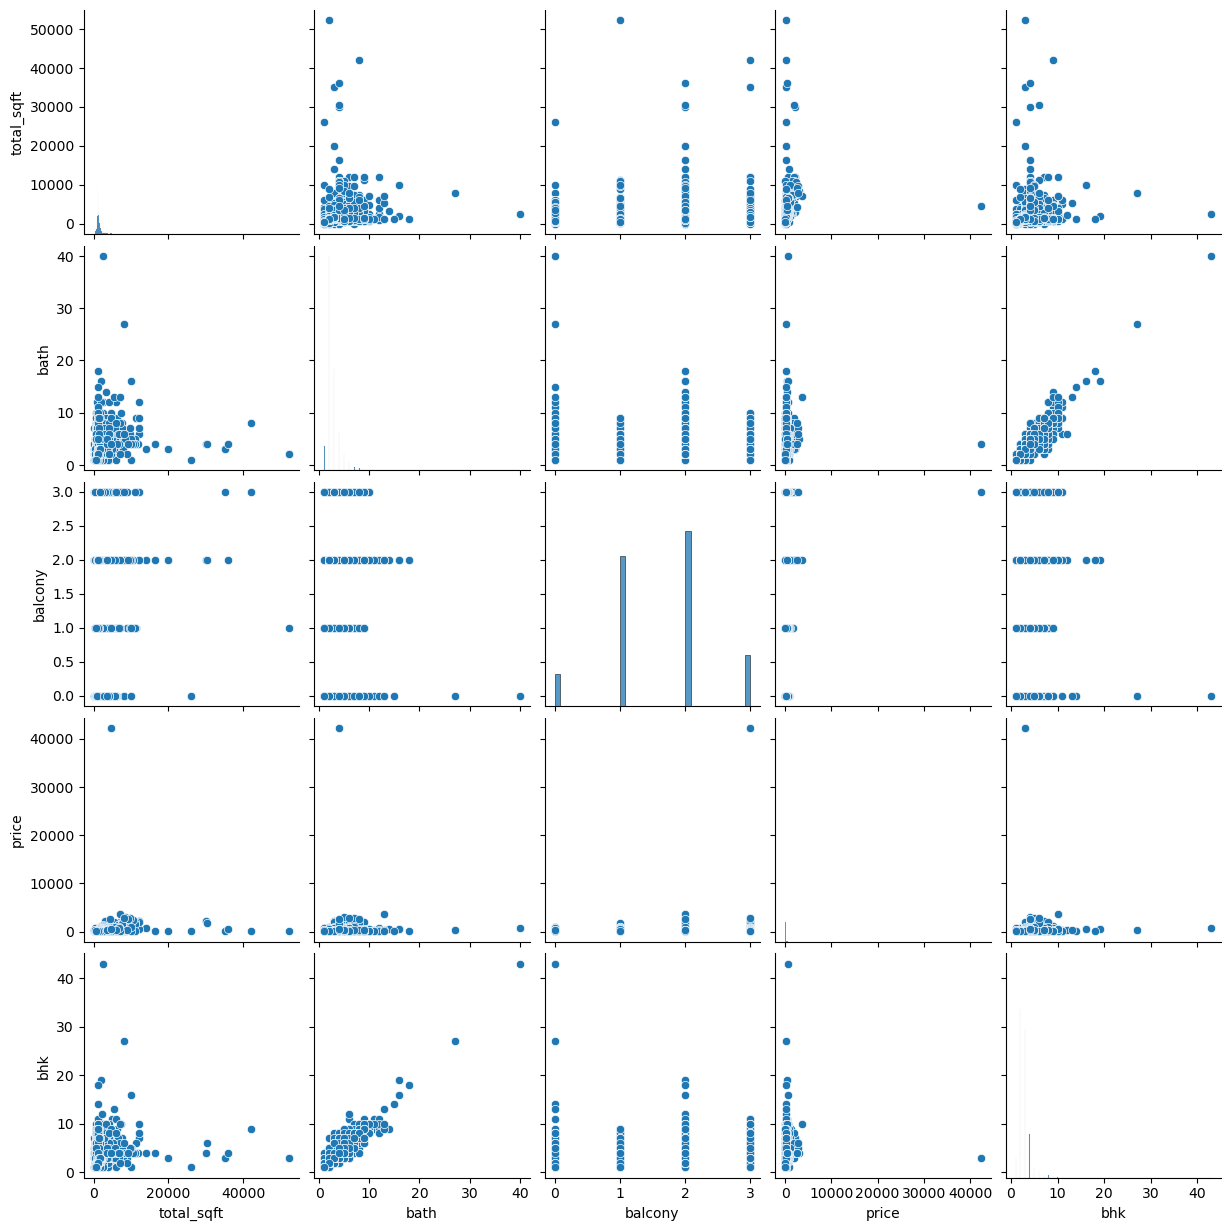

In [30]:
# Relationship b/w every numerical feature pair in a dataset
sns.pairplot(df)
plt.show()

# bathrooms and bhk have slightly linear correlation with some outliers

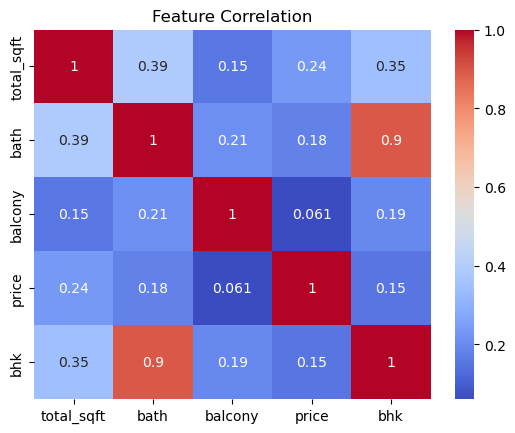

In [31]:
# Correlation heatmap

num_vars = ['total_sqft','bath','balcony','price','bhk']
sns.heatmap(df[num_vars].corr(), cmap='coolwarm', annot = True)
plt.title('Feature Correlation')
plt.show()

# Observed that bathrooms and bhk have stronger correlation with price comapared to total_sqft

In [32]:
# Separate Feature and Target column
X = df.drop(columns = ['price'])
y = df['price']

In [33]:
df.head(2)

,area_type,location,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,Electronic City Phase II,1056.0,2.0,1.0,39.07,2.0
1,Plot Area,Chikka Tirupathi,2600.0,5.0,3.0,120.00,4.0


In [34]:
# Encoding Categorical Columns
num_cols = ["total_sqft", "bath", "balcony", "bhk"] # Numerical coulums
cat_cols = ["area_type", "location"] # Categorical columns

# Create preprocessor
preprocessor = ColumnTransformer(transformers=[("num", StandardScaler(), num_cols),
                                               ("cat", OneHotEncoder(handle_unknown="ignore"),cat_cols)])

In [35]:
# Split data into Train & Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [36]:
# Create pipeline
lr_model = Pipeline(steps=[("preprocessor", preprocessor),("regressor", LinearRegression())])

In [37]:
# Train the model
lr_model.fit(X_train, y_train)

# make prediction on Test data
lr_pred= lr_model.predict(X_test)

# Regression Model Evaluation
print("Linear Regress R2 Score:", r2_score(y_test, lr_pred))
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("MSE:", mean_squared_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_absolute_error(y_test, lr_pred)))


Linear Regress R2 Score: 0.5839496520294065
MAE: 40.69114633258594
MSE: 8857.947484662971
RMSE: 6.378961226766153


## Lasso Regression

In [38]:
lasso_model = Pipeline([('preprocessor', preprocessor), ('model', Lasso(alpha = 0.01))])

lasso_model.fit(X_train, y_train)
lasso_pred = lasso_model.predict(X_test)
print('Lasso R2:', r2_score(y_test, lasso_pred))

Lasso R2: 0.5909982538920336


## Ridge Regression

In [39]:
ridge_model = Pipeline([('preprocessor', preprocessor), ('model', Ridge(alpha = 1.0))])

ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)
print('Ridge R2:', r2_score(y_test, ridge_pred))

Ridge R2: 0.6104284917859293


## Random Forest Regressor

In [40]:
rf_model = Pipeline([("preprocessor", preprocessor), ("model", RandomForestRegressor(n_estimators=400,
                                                                                     max_depth=18,
                                                                                     random_state=42))])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
print("Random Forest R2 score:", r2_score(y_test, rf_pred))

Random Forest R2 score: 0.6807944357675325


## XGBoost

In [41]:
xgb_model = Pipeline([("preprocessor", preprocessor), ("model", XGBRegressor(n_estimators=300,
                                                                             learning_rate=0.05,
                                                                             max_depth=6,
                                                                             random_state=42))])

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
print("XGBoost R2 score:", r2_score(y_test, xgb_pred))

XGBoost R2 score: 0.6944881742833182
